In [1]:
# install the dependencies (pandas, numpy, openpyxl for .xlsx, ...)
%pip install pandas numpy openpyxl matplotlib seaborn scikit-learn -q

# import the dependencies
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
# Rolling sales by borough: one Excel file per NYC borough under ./data
DATA_DIR = Path("data")

# (display name, filename) — values must be borough labels, not paths alone
BOROUGH_FILES = [
    ("Bronx", "rollingsales_bronx.xlsx"),
    ("Brooklyn", "rollingsales_brooklyn.xlsx"),
    ("Manhattan", "rollingsales_manhattan.xlsx"),
    ("Queens", "rollingsales_queens.xlsx"),
    ("Staten Island", "rollingsales_statenisland.xlsx"),
]

borough_frames: dict[str, pd.DataFrame] = {}
for borough, fname in BOROUGH_FILES:
    path = DATA_DIR / fname
    # First 4 rows are title/description; real table header starts on row 5
    df = pd.read_excel(path, skiprows=4)

    print(f"Shape of {borough} data: {df.shape}")

    borough_frames[borough] = df

# Remove any rows where the sale price is 0 or negative or missing
for borough in borough_frames:
    borough_frames[borough] = borough_frames[borough][borough_frames[borough]["SALE PRICE"].notna()]
    borough_frames[borough] = borough_frames[borough][borough_frames[borough]["SALE PRICE"] > 0]

sales = pd.concat(borough_frames.values(), ignore_index=True)

sales.shape, list(borough_frames.keys())

Shape of Bronx data: (6498, 21)
Shape of Brooklyn data: (22641, 21)
Shape of Manhattan data: (19163, 21)
Shape of Queens data: (26385, 21)
Shape of Staten Island data: (7036, 21)


((53956, 21), ['Bronx', 'Brooklyn', 'Manhattan', 'Queens', 'Staten Island'])

In [3]:
# analyzing columns of different boroughs
for borough in borough_frames:
    print(f"Columns of {borough} data: {borough_frames[borough].columns}")

# analyzing rows of different boroughs
for borough in borough_frames:
    print(f"Rows of {borough} data: {borough_frames[borough].shape[0]}")

Columns of Bronx data: Index(['BOROUGH', 'NEIGHBORHOOD', 'BUILDING CLASS CATEGORY',
       'TAX CLASS AT PRESENT', 'BLOCK', 'LOT', 'EASEMENT',
       'BUILDING CLASS AT PRESENT', 'ADDRESS', 'APARTMENT NUMBER', 'ZIP CODE',
       'RESIDENTIAL UNITS', 'COMMERCIAL UNITS', 'TOTAL UNITS',
       'LAND SQUARE FEET', 'GROSS SQUARE FEET', 'YEAR BUILT',
       'TAX CLASS AT TIME OF SALE', 'BUILDING CLASS AT TIME OF SALE',
       'SALE PRICE', 'SALE DATE'],
      dtype='str')
Columns of Brooklyn data: Index(['BOROUGH', 'NEIGHBORHOOD', 'BUILDING CLASS CATEGORY',
       'TAX CLASS AT PRESENT', 'BLOCK', 'LOT', 'EASEMENT',
       'BUILDING CLASS AT PRESENT', 'ADDRESS', 'APARTMENT NUMBER', 'ZIP CODE',
       'RESIDENTIAL UNITS', 'COMMERCIAL UNITS', 'TOTAL UNITS',
       'LAND SQUARE FEET', 'GROSS SQUARE FEET', 'YEAR BUILT',
       'TAX CLASS AT TIME OF SALE', 'BUILDING CLASS AT TIME OF SALE',
       'SALE PRICE', 'SALE DATE'],
      dtype='str')
Columns of Manhattan data: Index(['BOROUGH', 'NEIGHBORH

In [4]:
# Dropping irrelevant columns
columns_to_drop = ["BOROUGH", "APARTMENT NUMBER", "EASEMENT"]
for borough in borough_frames:
    try:
        borough_frames[borough] = borough_frames[borough].drop(columns=columns_to_drop)
    except KeyError:
        pass  # column already absent in this frame


In [5]:
# How empty is each column in each borough?
def is_nullish(s: pd.Series) -> pd.Series:
    null = s.isna()
    if s.dtype != object and not pd.api.types.is_string_dtype(s):
        return null
    empty_str = s.map(lambda x: isinstance(x, str) and x.strip() == "")
    return null | empty_str

# Fill in missing values for residential, commercial, and total units
for borough in borough_frames:
    df = borough_frames[borough]
    for idx, row in df.iterrows():
        residential_units = row["RESIDENTIAL UNITS"]
        commercial_units = row["COMMERCIAL UNITS"]
        total_units = row["TOTAL UNITS"]

        r_ok = pd.notna(residential_units) and not (
            isinstance(residential_units, str) and residential_units.strip() == ""
        )
        c_ok = pd.notna(commercial_units) and not (
            isinstance(commercial_units, str) and commercial_units.strip() == ""
        )
        t_ok = pd.notna(total_units) and not (
            isinstance(total_units, str) and total_units.strip() == ""
        )

        if not r_ok and t_ok and c_ok:
            residential_units = total_units - commercial_units
        elif not t_ok and r_ok and c_ok:
            total_units = residential_units + commercial_units
        elif not c_ok and t_ok and r_ok:
            commercial_units = total_units - residential_units

        df.loc[idx, "RESIDENTIAL UNITS"] = residential_units
        df.loc[idx, "COMMERCIAL UNITS"] = commercial_units
        df.loc[idx, "TOTAL UNITS"] = total_units

# Rebuild combined frame so later analysis sees imputed unit columns
sales = pd.concat(borough_frames.values(), ignore_index=True)

for borough in borough_frames:
    print(f"Percentage of empty values in {borough} data:")
    for col in borough_frames[borough].columns:
        pct = is_nullish(borough_frames[borough][col]).mean()
        print(f"{col}: {pct}")
    print()

Percentage of empty values in Bronx data:
NEIGHBORHOOD: 0.0
BUILDING CLASS CATEGORY: 0.0
TAX CLASS AT PRESENT: 0.0
BLOCK: 0.0
LOT: 0.0
BUILDING CLASS AT PRESENT: 0.0
ADDRESS: 0.0
ZIP CODE: 0.0
RESIDENTIAL UNITS: 0.22034296452901103
COMMERCIAL UNITS: 0.22034296452901103
TOTAL UNITS: 0.22034296452901103
LAND SQUARE FEET: 0.30913789053323937
GROSS SQUARE FEET: 0.30913789053323937
YEAR BUILT: 0.09701667841202725
TAX CLASS AT TIME OF SALE: 0.0
BUILDING CLASS AT TIME OF SALE: 0.0
SALE PRICE: 0.0
SALE DATE: 0.0

Percentage of empty values in Brooklyn data:
NEIGHBORHOOD: 0.0
BUILDING CLASS CATEGORY: 0.0
TAX CLASS AT PRESENT: 0.0
BLOCK: 0.0
LOT: 0.0
BUILDING CLASS AT PRESENT: 0.0
ADDRESS: 0.0
ZIP CODE: 7.126060001425212e-05
RESIDENTIAL UNITS: 0.16183282263236656
COMMERCIAL UNITS: 0.16183282263236656
TOTAL UNITS: 0.16183282263236656
LAND SQUARE FEET: 0.45934582769186916
GROSS SQUARE FEET: 0.45934582769186916
YEAR BUILT: 0.06719874581343975
TAX CLASS AT TIME OF SALE: 0.0
BUILDING CLASS AT TIME OF

In [6]:
# see what are the different tax classes in the data (for manhattan)
print("Building class categories:")
print(borough_frames["Manhattan"]["BUILDING CLASS CATEGORY"].unique())

print()

print("Tax class at time of sale:")
print(borough_frames["Manhattan"]["TAX CLASS AT TIME OF SALE"].unique())


Building class categories:
<StringArray>
[            '07 RENTALS - WALKUP APARTMENTS',
           '08 RENTALS - ELEVATOR APARTMENTS',
               '09 COOPS - WALKUP APARTMENTS',
             '10 COOPS - ELEVATOR APARTMENTS',
              '11 SPECIAL CONDO BILLING LOTS',
              '12 CONDOS - WALKUP APARTMENTS',
            '13 CONDOS - ELEVATOR APARTMENTS',
          '15 CONDOS - 2-10 UNIT RESIDENTIAL',
                             '17 CONDO COOPS',
                        '21 OFFICE BUILDINGS',
                                '34 THEATRES',
                   '46 CONDO STORE BUILDINGS',
                    '01 ONE FAMILY DWELLINGS',
                    '02 TWO FAMILY DWELLINGS',
                  '03 THREE FAMILY DWELLINGS',
                     '14 RENTALS - 4-10 UNIT',
 '16 CONDOS - 2-10 UNIT WITH COMMERCIAL UNIT',
                         '22 STORE BUILDINGS',
                           '25 LUXURY HOTELS',
                       '28 COMMERCIAL CONDOS',
                   

In [7]:
# Work with manhattan rentals
manhattan_rentals = borough_frames["Manhattan"][borough_frames["Manhattan"]["BUILDING CLASS CATEGORY"].str.upper().str.contains("RENTALS")]

# Total number of rentals
print("Total number of rentals:")
print(manhattan_rentals.shape[0])

# See what different Building class categories are there
print("Building class categories:")
print(manhattan_rentals["BUILDING CLASS CATEGORY"].unique())

# see the columns one more time
print(manhattan_rentals.columns)

Total number of rentals:
560
Building class categories:
<StringArray>
[  '07 RENTALS - WALKUP APARTMENTS', '08 RENTALS - ELEVATOR APARTMENTS',
           '14 RENTALS - 4-10 UNIT']
Length: 3, dtype: str
Index(['NEIGHBORHOOD', 'BUILDING CLASS CATEGORY', 'TAX CLASS AT PRESENT',
       'BLOCK', 'LOT', 'BUILDING CLASS AT PRESENT', 'ADDRESS', 'ZIP CODE',
       'RESIDENTIAL UNITS', 'COMMERCIAL UNITS', 'TOTAL UNITS',
       'LAND SQUARE FEET', 'GROSS SQUARE FEET', 'YEAR BUILT',
       'TAX CLASS AT TIME OF SALE', 'BUILDING CLASS AT TIME OF SALE',
       'SALE PRICE', 'SALE DATE'],
      dtype='str')


In [8]:
# check and see how many total units (min and max) are there for 07 Rentals, 08 Rentals, 14 Rentals each (basically find the range for each unique buidling class category)
for building_class in manhattan_rentals["BUILDING CLASS CATEGORY"].unique():
    print(building_class)
    print(manhattan_rentals[manhattan_rentals["BUILDING CLASS CATEGORY"] == building_class]["TOTAL UNITS"].min())
    print(manhattan_rentals[manhattan_rentals["BUILDING CLASS CATEGORY"] == building_class]["TOTAL UNITS"].max())
    print()


07 RENTALS - WALKUP APARTMENTS
1.0
86.0

08 RENTALS - ELEVATOR APARTMENTS
6.0
1097.0

14 RENTALS - 4-10 UNIT
4.0
12.0



In [9]:
# clean the data
# remove rows if missing sales price
manhattan_rentals = manhattan_rentals[manhattan_rentals["SALE PRICE"].notna()]

# check what columns are missing what percentage of data
for column in manhattan_rentals.columns:
    print(f"{column}: {manhattan_rentals[column].isna().mean()}")

# All columns are complete

# See how many data points we have here
print(manhattan_rentals.shape[0])
# 814


NEIGHBORHOOD: 0.0
BUILDING CLASS CATEGORY: 0.0
TAX CLASS AT PRESENT: 0.0
BLOCK: 0.0
LOT: 0.0
BUILDING CLASS AT PRESENT: 0.0
ADDRESS: 0.0
ZIP CODE: 0.0
RESIDENTIAL UNITS: 0.0
COMMERCIAL UNITS: 0.0
TOTAL UNITS: 0.0
LAND SQUARE FEET: 0.0
GROSS SQUARE FEET: 0.0
YEAR BUILT: 0.0
TAX CLASS AT TIME OF SALE: 0.0
BUILDING CLASS AT TIME OF SALE: 0.0
SALE PRICE: 0.0
SALE DATE: 0.0
560


In [10]:
# see the unique values in the neighborhood column
print(manhattan_rentals["NEIGHBORHOOD"].unique())

<StringArray>
[            'ALPHABET CITY',                   'CHELSEA',
                 'CHINATOWN',              'CIVIC CENTER',
                   'CLINTON',              'EAST VILLAGE',
                   'FASHION',                 'FINANCIAL',
                  'FLATIRON',                  'GRAMERCY',
 'GREENWICH VILLAGE-CENTRAL',    'GREENWICH VILLAGE-WEST',
            'HARLEM-CENTRAL',               'HARLEM-EAST',
              'HARLEM-UPPER',               'HARLEM-WEST',
                    'INWOOD',                  'KIPS BAY',
              'LITTLE ITALY',           'LOWER EAST SIDE',
          'MANHATTAN VALLEY',               'MIDTOWN CBD',
              'MIDTOWN EAST',              'MIDTOWN WEST',
       'MORNINGSIDE HEIGHTS',               'MURRAY HILL',
                      'SOHO',                   'TRIBECA',
   'UPPER EAST SIDE (59-79)',   'UPPER EAST SIDE (79-96)',
   'UPPER WEST SIDE (59-79)',   'UPPER WEST SIDE (79-96)',
  'UPPER WEST SIDE (96-116)',  'WASHINGTON

In [11]:
# deeper clean and feature engineering
def clean_and_feature_engineer(df: pd.DataFrame) -> pd.DataFrame:
    # remove address, sale date, tax class at present
    try:
        df = df.drop(columns=["ADDRESS", "SALE DATE", "TAX CLASS AT PRESENT"])
    except KeyError:
        pass

    # create a new column for each unique value in the neighborhood column (name it as NEIGHBORHOOD_<value>)
    for neighborhood in df["NEIGHBORHOOD"].unique():
        df[f"NEIGHBORHOOD_{neighborhood}"] = df["NEIGHBORHOOD"] == neighborhood

    # drop the original neighborhood column
    df = df.drop(columns=["NEIGHBORHOOD"])
    return df

# clean and feature engineer the data
manhattan_rentals = clean_and_feature_engineer(manhattan_rentals)

# see the number of total new columns
print(len(manhattan_rentals.columns))

49


In [12]:
# print the first 200 row values of TAX CLASS AT TIME OF SALE
print(manhattan_rentals["TAX CLASS AT TIME OF SALE"].nunique())
# it has only one unique value : 2

# remove the TAX CLASS AT TIME OF SALE column
manhattan_rentals = manhattan_rentals.drop(columns=["TAX CLASS AT TIME OF SALE"])

# see the number of total new columns
print(len(manhattan_rentals.columns))

1
48



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


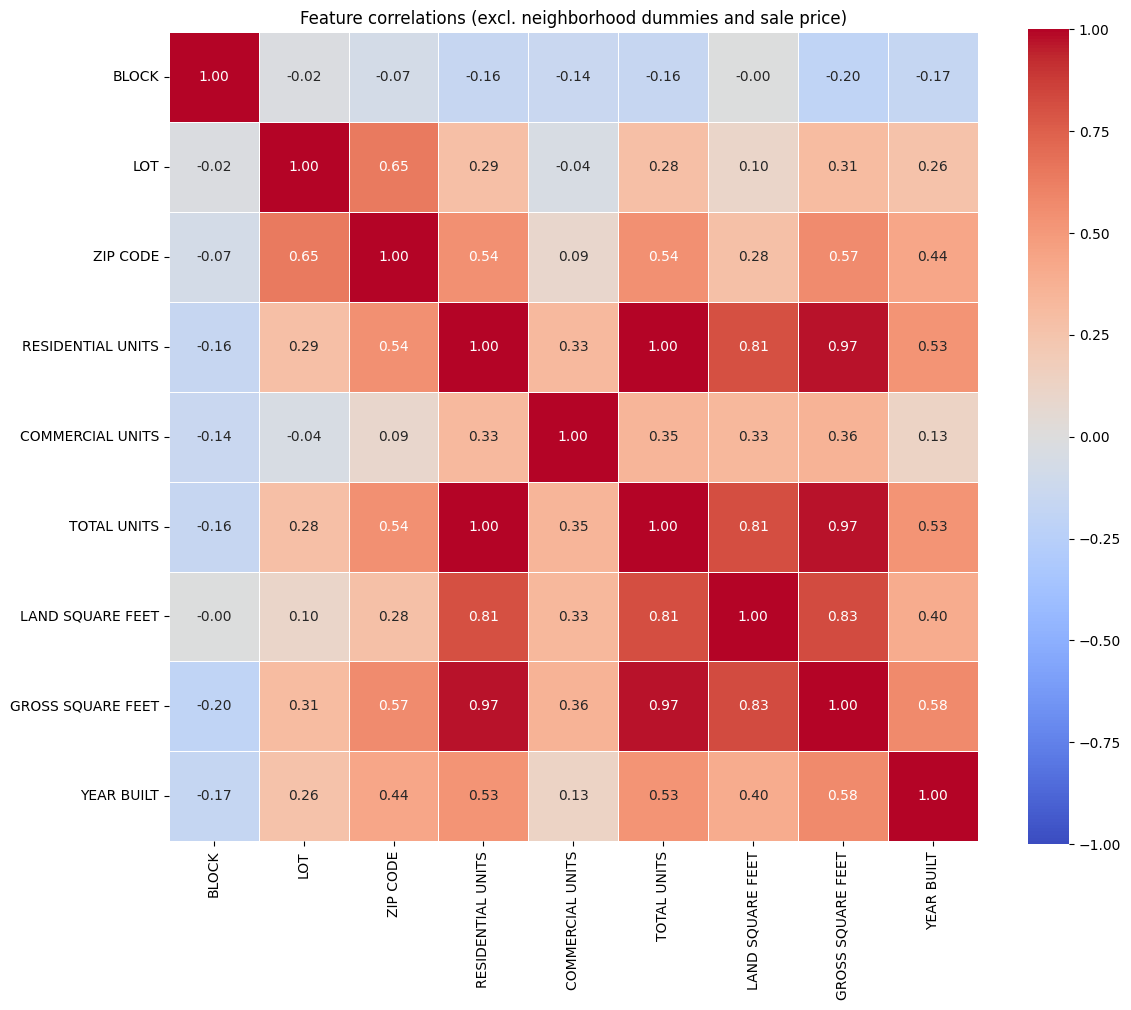

In [13]:
# install and import sns
%pip install seaborn -q
import seaborn as sns


# Create a correlation matrix for the features (do not include the neighborhood columns, neighborhood_<value>)
non_neighborhood_cols = [
    c for c in manhattan_rentals.columns if not c.startswith("NEIGHBORHOOD_")
]
feature_subset = manhattan_rentals[non_neighborhood_cols]
numeric_features = (
    feature_subset.select_dtypes(include=np.number)
    .drop(columns=["SALE PRICE"], errors="ignore")
)
corr_matrix = numeric_features.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
)
plt.title("Feature correlations (excl. neighborhood dummies and sale price)")
plt.tight_layout()
plt.show()


Outlier removal (IQR k=1.5 on AVERAGE UNIT DENSITY and COST PER SQ FT): dropped 43 rows (43 flagged among rows with both values finite).
  Density bounds kept: [-9.57385e-05, 0.00295543]   $/GSF bounds: [-1,233, 2,141]


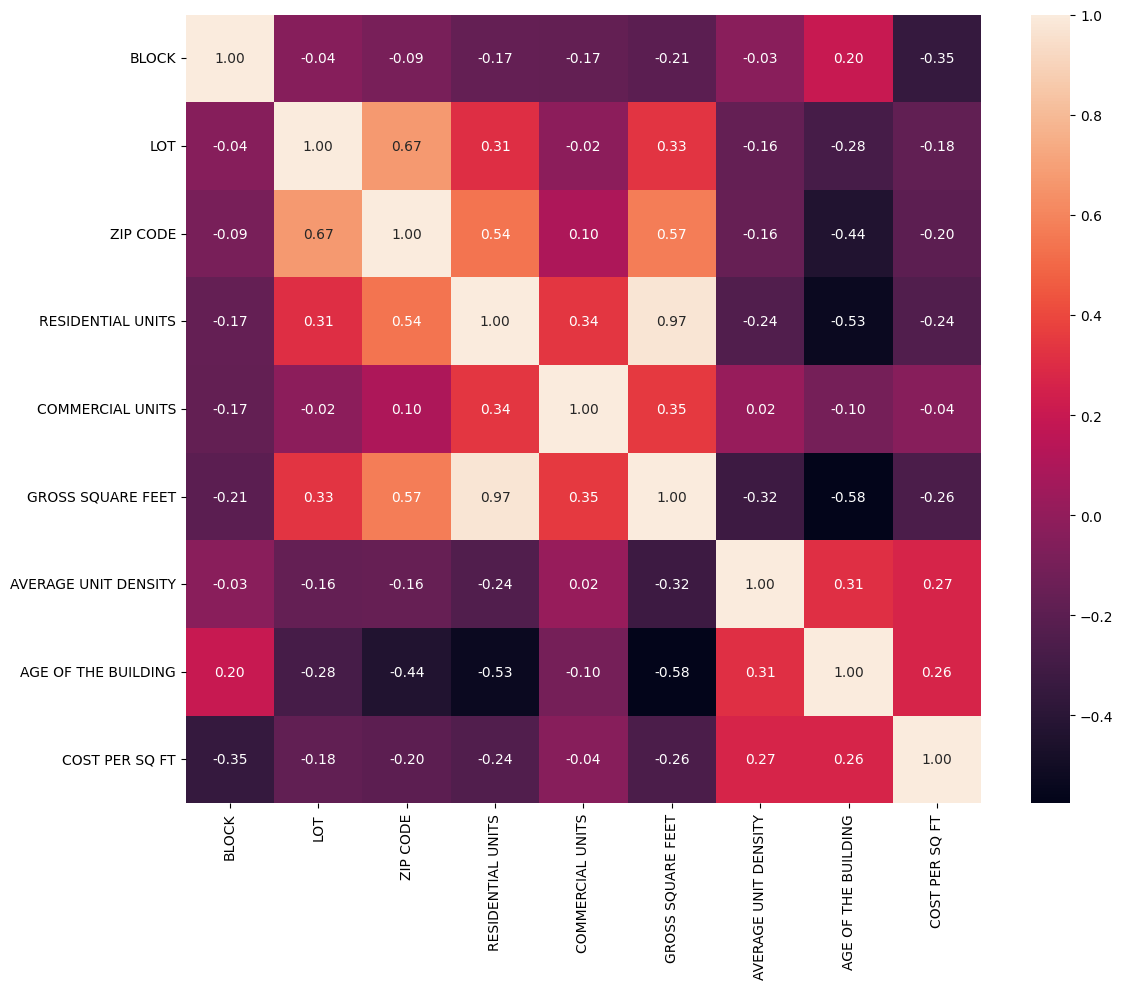

In [14]:
# create a new column for average unit density (total units / gross square feet)
manhattan_rentals["AVERAGE UNIT DENSITY"] = (manhattan_rentals["TOTAL UNITS"] + manhattan_rentals["COMMERCIAL UNITS"]) / manhattan_rentals["GROSS SQUARE FEET"]

# instead of year built, we can use the age of the building
manhattan_rentals["AGE OF THE BUILDING"] = 2026 - manhattan_rentals["YEAR BUILT"]
manhattan_rentals = manhattan_rentals.drop(columns=["YEAR BUILT"])

# remove the total units column (residential units and total units have a correlation of 1)
manhattan_rentals = manhattan_rentals.drop(columns=["TOTAL UNITS"])

# land square feet does not seem to be a very interesting feature when we have the gross square feet
manhattan_rentals = manhattan_rentals.drop(columns=["LAND SQUARE FEET"])

# Cost per gross square foot (sale price / GROSS SQUARE FEET)
_sale = pd.to_numeric(manhattan_rentals["SALE PRICE"], errors="coerce")
_gsf = pd.to_numeric(manhattan_rentals["GROSS SQUARE FEET"], errors="coerce")
manhattan_rentals["COST PER SQ FT"] = _sale / _gsf.replace(0, np.nan)

# Clean non-finite values before outlier logic
manhattan_rentals = manhattan_rentals.replace([np.inf, -np.inf], np.nan)


def _iqr_bounds(s: pd.Series, k: float = 1.5) -> tuple[float, float]:
    s = pd.to_numeric(s, errors="coerce").dropna()
    if len(s) < 4:
        return float("-inf"), float("inf")
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    if iqr <= 0 or not np.isfinite(iqr):
        return float(s.min()), float(s.max())
    return float(q1 - k * iqr), float(q3 + k * iqr)


# Remove rows that are IQR outliers in AVERAGE UNIT DENSITY or COST PER SQ FT (1.5 * IQR rule)
_dens = pd.to_numeric(manhattan_rentals["AVERAGE UNIT DENSITY"], errors="coerce")
_cost = pd.to_numeric(manhattan_rentals["COST PER SQ FT"], errors="coerce")
_both = _dens.notna() & _cost.notna()
_d_lo, _d_hi = _iqr_bounds(_dens[_both])
_c_lo, _c_hi = _iqr_bounds(_cost[_both])
_outlier = _both & (
    (_dens < _d_lo) | (_dens > _d_hi) | (_cost < _c_lo) | (_cost > _c_hi)
)
_n_before = len(manhattan_rentals)
manhattan_rentals = manhattan_rentals.loc[~_outlier].copy()
print(
    f"Outlier removal (IQR k=1.5 on AVERAGE UNIT DENSITY and COST PER SQ FT): "
    f"dropped {_n_before - len(manhattan_rentals)} rows ({_outlier.sum()} flagged among rows with both values finite)."
)
print(f"  Density bounds kept: [{_d_lo:.6g}, {_d_hi:.6g}]   $/GSF bounds: [{_c_lo:,.0f}, {_c_hi:,.0f}]")

# create a new heatmap for the correlation matrix (excluding the neighborhood columns and sale price)
non_neighborhood_cols = [
    c for c in manhattan_rentals.columns if not c.startswith("NEIGHBORHOOD_")
]
feature_subset = manhattan_rentals[non_neighborhood_cols]
numeric_features = (
    feature_subset.select_dtypes(include=np.number)
    .drop(columns=["SALE PRICE"], errors="ignore")
)

plt.figure(figsize=(12, 10))
sns.heatmap(
    numeric_features.corr(),
    annot=True,
    fmt=".2f",
)
plt.tight_layout()
plt.show()


Multivariate log–log (log price ~ log(res) + log1p(comm) + log(gsf)) on rows with res>0, gsf>0, price>0:
  coef log(residential units): 0.4743  (~elasticity w.r.t. res units, holding others fixed)
  coef log1p(commercial units): 0.8618  (not a pure elasticity; interpret via curves)
  coef log(gross sq ft): -0.4591  (~elasticity w.r.t. GSF, holding others fixed)
  R^2: 0.024   n = 517



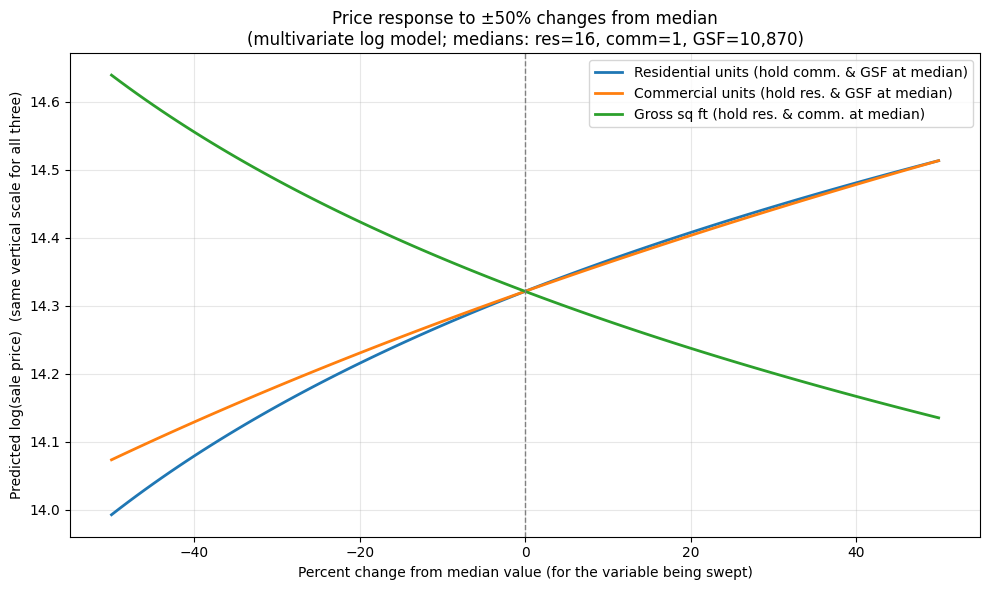

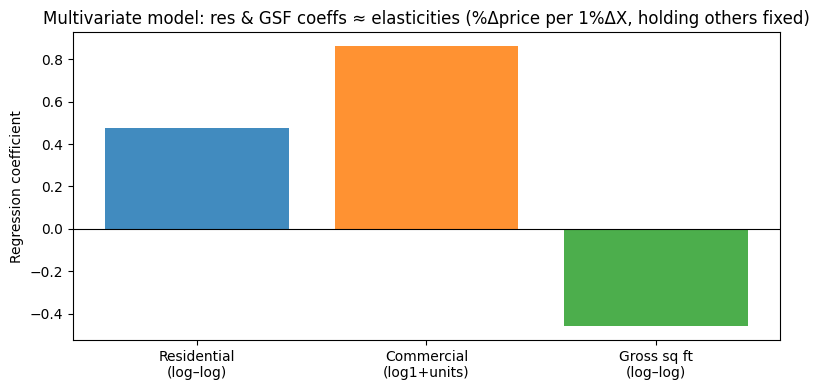

In [15]:
# Relationship of sale price to residential units, commercial units, and gross sq ft
# Standard approach: multivariate log–log regression. Coefficients are *elasticities* (approx.):
# "1% higher residential units → β1% higher price" holding commercial and GSF fixed (same for GSF).
# Commercial often has zeros, so we use log(1 + commercial units); that coefficient is not a clean
# elasticity at zero, but the curves below still show how predicted price moves with %-changes from typical levels.

from sklearn.linear_model import LinearRegression

_df = manhattan_rentals.copy()
p = pd.to_numeric(_df["SALE PRICE"], errors="coerce")
ru = pd.to_numeric(_df["RESIDENTIAL UNITS"], errors="coerce")
cu = pd.to_numeric(_df["COMMERCIAL UNITS"], errors="coerce")
gsf = pd.to_numeric(_df["GROSS SQUARE FEET"], errors="coerce")

ok = (p > 0) & (ru > 0) & (gsf > 0)
p, ru, cu, gsf = p[ok], ru[ok], cu[ok], gsf[ok]

y = np.log(p.values)
X = np.column_stack(
    [np.log(ru.values), np.log1p(cu.values), np.log(gsf.values)]
)
model = LinearRegression().fit(X, y)

b_ru, b_cu, b_gsf = model.coef_
print("Multivariate log–log (log price ~ log(res) + log1p(comm) + log(gsf)) on rows with res>0, gsf>0, price>0:")
print(f"  coef log(residential units): {b_ru:.4f}  (~elasticity w.r.t. res units, holding others fixed)")
print(f"  coef log1p(commercial units): {b_cu:.4f}  (not a pure elasticity; interpret via curves)")
print(f"  coef log(gross sq ft): {b_gsf:.4f}  (~elasticity w.r.t. GSF, holding others fixed)")
print(f"  R^2: {model.score(X, y):.3f}   n = {len(y)}")
print()

# Same graph: %-change from median on x, predicted log(price) on y (parallel trends on log scale = multiplicative in $)
med_ru = float(ru.median())
med_cu = float(cu.median())
med_gsf = float(gsf.median())
pct = np.linspace(-50, 50, 100)

ru_sweep = np.maximum(med_ru * (1 + pct / 100.0), 1e-9)
Xr = np.column_stack(
    [
        np.log(ru_sweep),
        np.full_like(pct, np.log1p(med_cu), dtype=float),
        np.full_like(pct, np.log(med_gsf), dtype=float),
    ]
)
cu_sweep = np.maximum(med_cu * (1 + pct / 100.0), 0.0)
Xc = np.column_stack(
    [
        np.full_like(pct, np.log(med_ru), dtype=float),
        np.log1p(cu_sweep),
        np.full_like(pct, np.log(med_gsf), dtype=float),
    ]
)
gsf_sweep = np.maximum(med_gsf * (1 + pct / 100.0), 1e-9)
Xg = np.column_stack(
    [
        np.full_like(pct, np.log(med_ru), dtype=float),
        np.full_like(pct, np.log1p(med_cu), dtype=float),
        np.log(gsf_sweep),
    ]
)

y_r, y_c, y_g = model.predict(Xr), model.predict(Xc), model.predict(Xg)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(pct, y_r, label="Residential units (hold comm. & GSF at median)", color="tab:blue", lw=2)
ax.plot(pct, y_c, label="Commercial units (hold res. & GSF at median)", color="tab:orange", lw=2)
ax.plot(pct, y_g, label="Gross sq ft (hold res. & comm. at median)", color="tab:green", lw=2)
ax.axvline(0, color="gray", ls="--", lw=1)
ax.set_xlabel("Percent change from median value (for the variable being swept)")
ax.set_ylabel("Predicted log(sale price)  (same vertical scale for all three)")
ax.set_title(
    "Price response to ±50% changes from median\n(multivariate log model; medians: "
    f"res={med_ru:.0f}, comm={med_cu:.0f}, GSF={med_gsf:,.0f})"
)
ax.legend(loc="best")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

fig2, ax2 = plt.subplots(figsize=(8, 4))
elasticity_labels = [
    "Residential\n(log–log)",
    "Commercial\n(log1+units)",
    "Gross sq ft\n(log–log)",
]
ax2.bar(
    elasticity_labels,
    [b_ru, b_cu, b_gsf],
    color=["tab:blue", "tab:orange", "tab:green"],
    alpha=0.85,
)
ax2.axhline(0, color="black", lw=0.8)
ax2.set_ylabel("Regression coefficient")
ax2.set_title(
    "Multivariate model: res & GSF coeffs ≈ elasticities (%Δprice per 1%ΔX, holding others fixed)"
)
plt.tight_layout()
plt.show()


1) Correlation among predictors (high values → multicollinearity)
            log_res  log1p_comm  log_gsf
log_res       1.000       0.301    0.928
log1p_comm    0.301       1.000    0.384
log_gsf       0.928       0.384    1.000

2) Variance inflation factors (VIF > ~5–10 often flagged as worrisome)
   log(residential units): VIF = 7.37
   log1p(commercial units): VIF = 1.20
   log(gross sq ft): VIF = 7.85

3) Simple log–log slope (one x at a time) vs partial slope (all three together)
predictor                     simple (marginal)    partial (OLS)  note
---------------------------------------------------------------------------
log(residential units)                   0.1610           0.4743  
log1p(commercial units)                  0.7790           0.8618  
log(gross sq ft)                         0.1218          -0.4591  sign flip vs simple

   R² multivariate model: 0.024

Interpretation: a *negative* partial coef on log(GSF) means: holding residential and commercial counts fixe

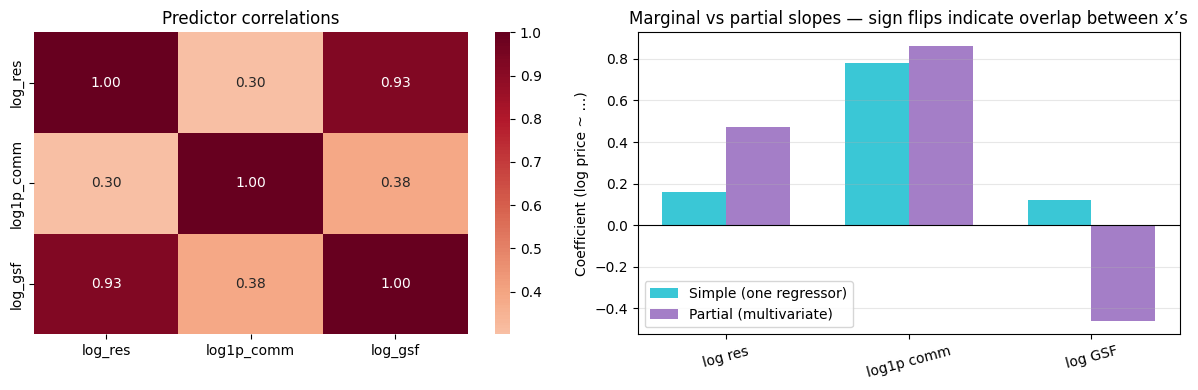

In [16]:
# Research follow-up: bivariate vs partial coefficients (why signs/magnitudes can surprise)
# The multivariate log model gives *partial* elasticities: effect of one variable when others are fixed.
# Residential units, commercial units, and GSF move together (bigger buildings → more of everything).
# Strong overlap inflates variance and can flip a slope vs a simple log–log regression.

from sklearn.linear_model import LinearRegression
import seaborn as sns

_df = manhattan_rentals.copy()
p = pd.to_numeric(_df["SALE PRICE"], errors="coerce")
ru = pd.to_numeric(_df["RESIDENTIAL UNITS"], errors="coerce")
cu = pd.to_numeric(_df["COMMERCIAL UNITS"], errors="coerce")
gsf = pd.to_numeric(_df["GROSS SQUARE FEET"], errors="coerce")
ok = (p > 0) & (ru > 0) & (gsf > 0)
p, ru, cu, gsf = p[ok], ru[ok], cu[ok], gsf[ok]

y = np.log(p.values)
lr = np.log(ru.values)
lc = np.log1p(cu.values)
lg = np.log(gsf.values)
Xfull = np.column_stack([lr, lc, lg])
names = ["log(residential units)", "log1p(commercial units)", "log(gross sq ft)"]

pred_df = pd.DataFrame({"log_res": lr, "log1p_comm": lc, "log_gsf": lg})
print("1) Correlation among predictors (high values → multicollinearity)")
print(pred_df.corr().round(3).to_string())
print()

# Variance inflation factor: VIF_j = 1 / (1 - R²) regressing x_j on the other predictors


def vif_matrix(X: np.ndarray, j: int) -> float:
    yv = X[:, j]
    others = np.delete(X, j, axis=1)
    r2 = LinearRegression().fit(others, yv).score(others, yv)
    if r2 >= 0.999:
        return float("inf")
    return 1.0 / (1.0 - r2)


print("2) Variance inflation factors (VIF > ~5–10 often flagged as worrisome)")
for j, n in enumerate(names):
    print(f"   {n}: VIF = {vif_matrix(Xfull, j):.2f}")
print()

# Bivariate (marginal) vs multivariate (partial) slopes
simple_coefs = []
for xj in (lr.reshape(-1, 1), lc.reshape(-1, 1), lg.reshape(-1, 1)):
    simple_coefs.append(LinearRegression().fit(xj, y).coef_[0])
multi_model = LinearRegression().fit(Xfull, y)
partial_coefs = multi_model.coef_.tolist()
r2_multi = multi_model.score(Xfull, y)

print("3) Simple log–log slope (one x at a time) vs partial slope (all three together)")
print(f"{'predictor':<28} {'simple (marginal)':>18} {'partial (OLS)':>16}  note")
print("-" * 75)
for n, s, m in zip(names, simple_coefs, partial_coefs):
    flip = "sign flip vs simple" if (s > 0) != (m > 0) else ""
    print(f"{n:<28} {s:>18.4f} {m:>16.4f}  {flip}")
print(f"\n   R² multivariate model: {r2_multi:.3f}")
print()
print(
    "Interpretation: a *negative* partial coef on log(GSF) means: holding residential and commercial"
    " counts fixed, more gross area is associated with *lower* predicted price — e.g. larger"
    " footprints per unit / less intensive use, or a statistical artifact if predictors are almost"
    " redundant. Check VIF and correlations above."
)
print()

# Design matrix condition number (with intercept) — huge values mean unstable OLS
X_int = np.column_stack([np.ones(len(y)), Xfull])
cond = np.linalg.cond(X_int)
print(f"4) Condition number of [intercept | X] (ill-conditioned if very large): {cond:.2e}")
print()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.heatmap(pred_df.corr(), annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=axes[0])
axes[0].set_title("Predictor correlations")

xpos = np.arange(len(names))
w = 0.35
axes[1].bar(xpos - w / 2, simple_coefs, width=w, label="Simple (one regressor)", color="tab:cyan", alpha=0.85)
axes[1].bar(xpos + w / 2, partial_coefs, width=w, label="Partial (multivariate)", color="tab:purple", alpha=0.85)
axes[1].axhline(0, color="black", lw=0.8)
axes[1].set_xticks(xpos)
axes[1].set_xticklabels(["log res", "log1p comm", "log GSF"], rotation=15)
axes[1].set_ylabel("Coefficient (log price ~ …)")
axes[1].set_title("Marginal vs partial slopes — sign flips indicate overlap between x’s")
axes[1].legend()
axes[1].grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()




[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
All features ranked (highest importance first):
GROSS SQUARE FEET                                           3.740066e-01
COST PER SQ FT                                              2.666943e-01
RESIDENTIAL UNITS                                           1.812524e-01
LOT                                                         6.877411e-02
COMMERCIAL UNITS                                            3.273173e-02
NEIGHBORHOOD_CLINTON                                        2.622500e-02
ZIP CODE                                                    1.552913e-02
AGE OF THE BUILDING                                         1.289757e-02
AVERAGE UNIT DENSITY                                        6.245394e-03
BLOCK                                                       5.686704e-03
BUILDING CLASS AT PRESENT_D3                 

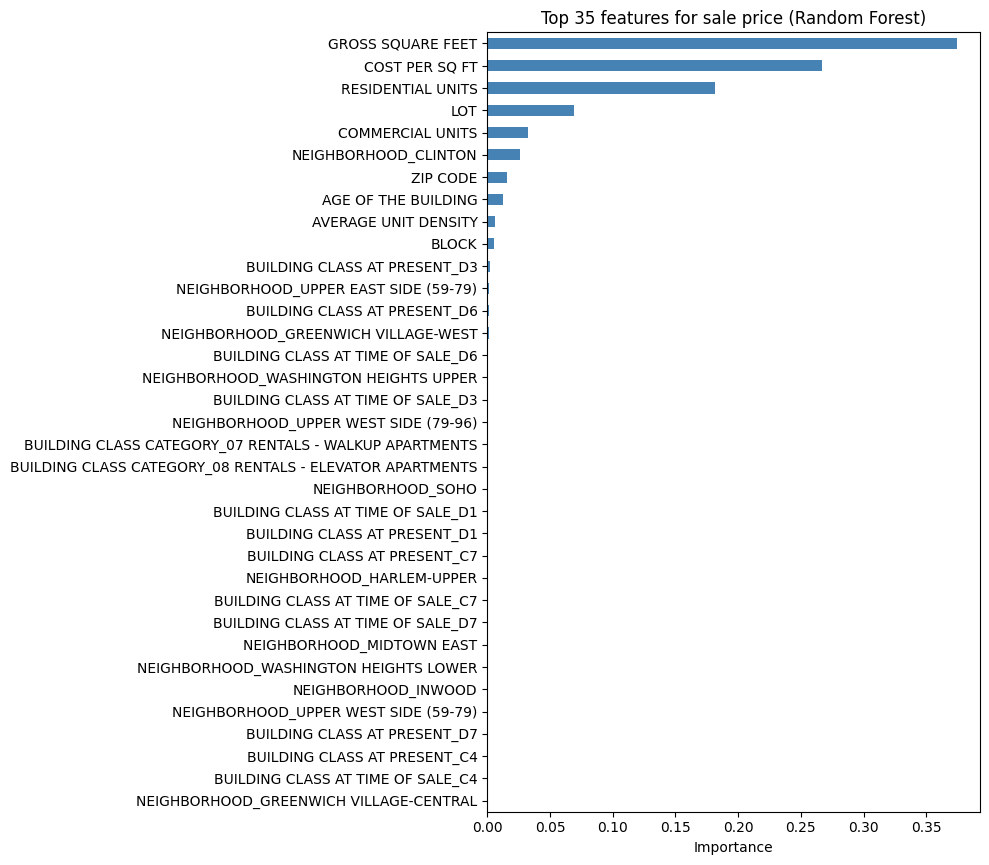

In [17]:
# Rank features by how much they help predict sale price (Random Forest importances)

# install and import the random forest regressor
%pip install scikit-learn -q

from sklearn.ensemble import RandomForestRegressor

y = pd.to_numeric(manhattan_rentals["SALE PRICE"], errors="coerce")
X = manhattan_rentals.drop(columns=["SALE PRICE"])
ok = y.notna()
X, y = X.loc[ok], y.loc[ok]

obj_cols = X.select_dtypes(include=["object", "string", "category"]).columns
X_enc = pd.get_dummies(X, columns=list(obj_cols), drop_first=False)

rf = RandomForestRegressor(
    n_estimators=400,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
)
rf.fit(X_enc, y)

ranked = pd.Series(rf.feature_importances_, index=X_enc.columns, name="importance").sort_values(
    ascending=False
)

print("All features ranked (highest importance first):")
print(ranked.to_string())
print()

top_n = min(35, len(ranked))
fig, ax = plt.subplots(figsize=(10, max(5, top_n * 0.25)))
ranked.head(top_n).iloc[::-1].plot(kind="barh", ax=ax, color="steelblue", legend=False)
ax.set_xlabel("Importance")
ax.set_title(f"Top {top_n} features for sale price (Random Forest)")
plt.tight_layout()
plt.show()


In [18]:
# Compare ML architectures for sale price (same encodings as the Random Forest cell)
# Target: log1p(SALE PRICE) to tame skew; test metrics shown in dollars via expm1(predictions).
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y = pd.to_numeric(manhattan_rentals["SALE PRICE"], errors="coerce")
X = manhattan_rentals.drop(columns=["SALE PRICE"])
ok = y.notna()
X, y = X.loc[ok], y.loc[ok].astype(float)

obj_cols = X.select_dtypes(include=["object", "string", "category"]).columns
X_enc = pd.get_dummies(X, columns=list(obj_cols), drop_first=False)
X_enc = X_enc.apply(pd.to_numeric, errors="coerce").fillna(0)

y_log = np.log1p(y)

X_train, X_test, y_train_log, y_test_log, y_train_raw, y_test_raw = train_test_split(
    X_enc, y_log, y, test_size=0.2, random_state=42
)

models = {
    "Ridge — linear model, global weights + L2 shrinkage (scaled X)": Pipeline(
        [
            ("scaler", StandardScaler()),
            ("ridge", Ridge(alpha=5.0, random_state=42)),
        ]
    ),
    "RandomForest — parallel deep trees, vote/average (bagging)": RandomForestRegressor(
        n_estimators=300,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1,
    ),
    "HistGradientBoosting — sequential shallow trees correct residuals": HistGradientBoostingRegressor(
        max_iter=300,
        max_depth=8,
        learning_rate=0.08,
        random_state=42,
    ),
}

rows = []
for name, est in models.items():
    est.fit(X_train, y_train_log)
    pred_log = est.predict(X_test)
    pred_raw = np.expm1(pred_log)
    rmse = float(np.sqrt(mean_squared_error(y_test_raw, pred_raw)))
    rows.append(
        {
            "model": name.split(" — ")[0].strip(),
            "MAE ($)": mean_absolute_error(y_test_raw, pred_raw),
            "RMSE ($)": rmse,
            "R² on $ (expm1)": r2_score(y_test_raw, pred_raw),
            "R² on log1p": r2_score(y_test_log, pred_log),
        }
    )

summary = pd.DataFrame(rows)
print("Holdout test (20%). Architecture one-liners:")
for name in models:
    print(f"  • {name}")
print()
print(
    summary.to_string(
        index=False,
        formatters={
            "MAE ($)": lambda v: f"${v:,.0f}",
            "RMSE ($)": lambda v: f"${v:,.0f}",
            "R² on $ (expm1)": lambda v: f"{v:.3f}",
            "R² on log1p": lambda v: f"{v:.3f}",
        },
    )
)
print()

cv_folds = 5
print(f"{cv_folds}-fold CV on full data — mean test MAE on log1p(price) (lower is better):")
for name, est in models.items():
    scores = -cross_val_score(
        est,
        X_enc,
        y_log,
        cv=cv_folds,
        scoring="neg_mean_absolute_error",
        n_jobs=-1,
    )
    short = name.split(" — ")[0].strip()
    print(f"  {short}: {scores.mean():.4f} (+/- {scores.std():.4f})")

print()
print(
    "Why numbers differ: Ridge only fits a single linear structure in log-space; RandomForest and "
    "HistGradientBoosting split feature space into rectangles and can approximate interactions "
    "(e.g. neighborhood × size). Boosting often edges RF on tabular data by reducing bias stepwise. "
    "High collinearity hurts interpretability of Ridge coefficients less than it hurts comparing "
    "absolute coefficient sizes to tree importances — use this table for prediction quality, RF/SHAP "
    "for non-linear drivers."
)


Holdout test (20%). Architecture one-liners:
  • Ridge — linear model, global weights + L2 shrinkage (scaled X)
  • RandomForest — parallel deep trees, vote/average (bagging)
  • HistGradientBoosting — sequential shallow trees correct residuals

               model     MAE ($)     RMSE ($) R² on $ (expm1) R² on log1p
               Ridge $30,071,975 $117,950,078         -23.236       0.305
        RandomForest  $2,232,982  $17,637,032           0.458       0.990
HistGradientBoosting  $2,113,774  $15,185,350           0.598       0.970

5-fold CV on full data — mean test MAE on log1p(price) (lower is better):
  Ridge: 2.1577 (+/- 0.3056)
  RandomForest: 0.3039 (+/- 0.1550)
  HistGradientBoosting: 0.3326 (+/- 0.1316)

Why numbers differ: Ridge only fits a single linear structure in log-space; RandomForest and HistGradientBoosting split feature space into rectangles and can approximate interactions (e.g. neighborhood × size). Boosting often edges RF on tabular data by reducing bias stepw

Neighborhoods in this slice: 35

Sale price, mean basketballs in the implied unit room (GROSS SF / units, 8 ft ceiling, 9.5 in ball, 64% volume packing), and mean $ / gross sq ft (sorted by median price, high to low):
                           n_sales median_price   mean_price    std_price    min_price     max_price mean_basketballs mean_price_per_gsf
NEIGHBORHOOD                                                                                                                            
FINANCIAL                        1  $10,250,000  $10,250,000               $10,250,000   $10,250,000                7            $816.08
LITTLE ITALY                    12   $9,850,000   $7,839,834   $7,352,378          $10   $23,400,000                5            $861.85
SOHO                            16   $9,750,000  $10,646,250   $8,116,364   $1,685,000   $25,000,000                9            $736.37
GREENWICH VILLAGE-CENTRAL       15   $9,400,000   $8,287,650   $3,461,242   $1,969,750   $14,275,

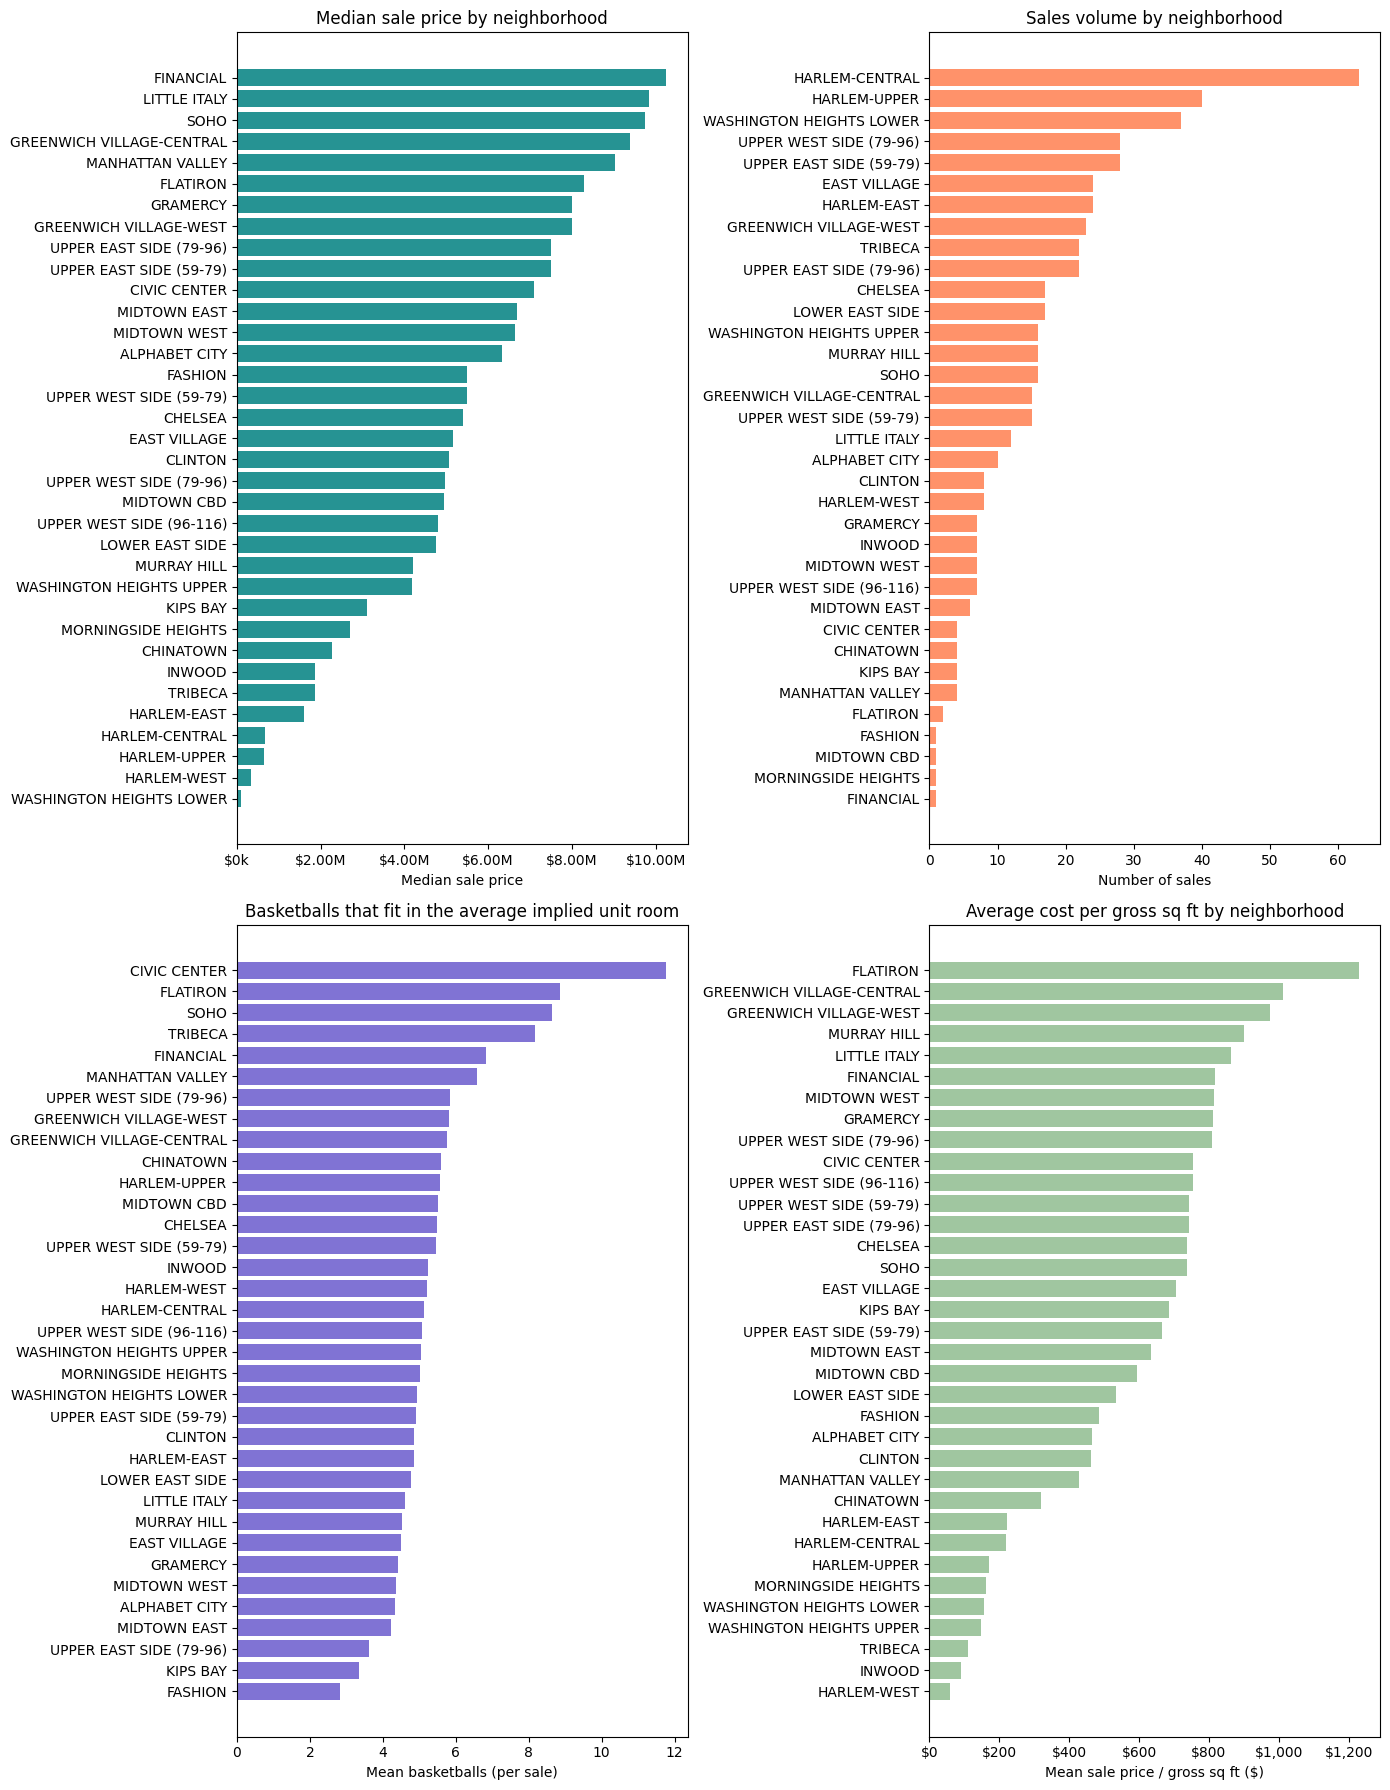

In [19]:
# Neighborhood analysis (Manhattan rentals — sale price by area)
# Reconstruct neighborhood from one-hot columns (original NEIGHBORHOOD was dropped earlier)
hood_cols = [c for c in manhattan_rentals.columns if c.startswith("NEIGHBORHOOD_")]
if not hood_cols:
    raise ValueError("No NEIGHBORHOOD_* columns found — run feature-engineering cells first.")

# --- Basketball count (easy mental model) ---
# Each sale: "room" floor area = gross sq ft / (res + comm units); 8 ft ceiling.
# NBA ball ~9.5 in diameter; packing_fraction 0.64 ≈ random sphere fill in a box (rough).


def approx_basketballs_in_room(
    floor_sqft: pd.Series,
    ceiling_ft: float = 8.0,
    ball_diameter_in: float = 9.5,
    packing_fraction: float = 0.64,
) -> pd.Series:
    d_ft = ball_diameter_in / 12.0
    r_ft = d_ft / 2.0
    # vol_ball = (4.0 / 3.0) * np.pi * r_ft**3
    vol_ball = ball_diameter_in ** 3 # think of it as a cube
    vol_room = floor_sqft.astype(float) * ceiling_ft
    return (vol_room / vol_ball) * packing_fraction


hood_matrix = manhattan_rentals[hood_cols]
neighborhood = hood_matrix.idxmax(axis=1).str.removeprefix("NEIGHBORHOOD_")
price = pd.to_numeric(manhattan_rentals["SALE PRICE"], errors="coerce")
gsf = pd.to_numeric(manhattan_rentals["GROSS SQUARE FEET"], errors="coerce")
ru = pd.to_numeric(manhattan_rentals["RESIDENTIAL UNITS"], errors="coerce")
cu = pd.to_numeric(manhattan_rentals["COMMERCIAL UNITS"], errors="coerce")

units = ru.fillna(0) + cu.fillna(0)
floor_per_unit = gsf / units.replace(0, np.nan)
basketballs = approx_basketballs_in_room(floor_per_unit)

price_per_gsf = price / gsf.replace(0, float("nan"))

nb_df = pd.DataFrame(
    {
        "NEIGHBORHOOD": neighborhood,
        "SALE_PRICE": price,
        "basketballs": basketballs,
        "price_per_gsf": price_per_gsf,
    }
).dropna(subset=["SALE_PRICE"])

nb_stats = (
    nb_df.dropna(subset=["basketballs"])
    .replace([float("inf"), float("-inf")], float("nan"))
    .dropna(subset=["basketballs"])
    .groupby("NEIGHBORHOOD", observed=True)
    .agg(
        n_sales=("SALE_PRICE", "count"),
        median_price=("SALE_PRICE", "median"),
        mean_price=("SALE_PRICE", "mean"),
        std_price=("SALE_PRICE", "std"),
        min_price=("SALE_PRICE", "min"),
        max_price=("SALE_PRICE", "max"),
        mean_basketballs=("basketballs", "mean"),
        mean_price_per_gsf=("price_per_gsf", "mean"),
    )
    .sort_values("median_price", ascending=False)
)

print(f"Neighborhoods in this slice: {nb_stats.shape[0]}")
print()
print(
    "Sale price, mean basketballs in the implied unit room "
    "(GROSS SF / units, 8 ft ceiling, 9.5 in ball, 64% volume packing), "
    "and mean $ / gross sq ft (sorted by median price, high to low):"
)
pd.set_option("display.max_rows", None)
pd.set_option("display.width", 150)
tbl = nb_stats.copy()
for c in ["median_price", "mean_price", "std_price", "min_price", "max_price"]:
    tbl[c] = tbl[c].map(lambda x: f"${x:,.0f}" if pd.notna(x) else "")
tbl["mean_basketballs"] = tbl["mean_basketballs"].map(lambda x: f"{x:,.0f}" if pd.notna(x) else "")
tbl["mean_price_per_gsf"] = tbl["mean_price_per_gsf"].map(lambda x: f"${x:,.2f}" if pd.notna(x) else "")
print(tbl.to_string())
pd.reset_option("display.max_rows")
pd.reset_option("display.width")
print()

nhoods = nb_stats.shape[0]
fig, axes = plt.subplots(2, 2, figsize=(14, max(18, nhoods * 0.4)))

plot_med = nb_stats["median_price"].sort_values(ascending=True)
axes[0, 0].barh(plot_med.index, plot_med.values, color="teal", alpha=0.85)
axes[0, 0].set_xlabel("Median sale price")
axes[0, 0].set_title("Median sale price by neighborhood")
axes[0, 0].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f"${x/1e6:.2f}M" if x >= 1e6 else f"${x/1e3:.0f}k")
)

plot_n = nb_stats["n_sales"].sort_values(ascending=True)
axes[0, 1].barh(plot_n.index, plot_n.values, color="coral", alpha=0.85)
axes[0, 1].set_xlabel("Number of sales")
axes[0, 1].set_title("Sales volume by neighborhood")

bb_plot = nb_stats["mean_basketballs"].sort_values(ascending=True)
axes[1, 0].barh(bb_plot.index, bb_plot.values, color="slateblue", alpha=0.85)
axes[1, 0].set_xlabel("Mean basketballs (per sale)")
axes[1, 0].set_title("Basketballs that fit in the average implied unit room")
axes[1, 0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"{x:,.0f}"))

ppsf_plot = nb_stats["mean_price_per_gsf"].sort_values(ascending=True)
axes[1, 1].barh(ppsf_plot.index, ppsf_plot.values, color="darkseagreen", alpha=0.85)
axes[1, 1].set_xlabel("Mean sale price / gross sq ft ($)")
axes[1, 1].set_title("Average cost per gross sq ft by neighborhood")
axes[1, 1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"${x:,.0f}"))

plt.tight_layout()
plt.show()


In [20]:
# Rank neighborhoods by number of sales rows (top 10 / bottom 10)
_hc = [c for c in manhattan_rentals.columns if c.startswith("NEIGHBORHOOD_")]
_df = manhattan_rentals.assign(
    NEIGHBORHOOD=manhattan_rentals[_hc].idxmax(axis=1).str.removeprefix("NEIGHBORHOOD_")
)
by_rows = _df.groupby("NEIGHBORHOOD", observed=True).size().sort_values(ascending=False)
print("Top 10 neighborhoods by number of sales (rows)")
print(by_rows.head(10).to_string())
print()
print("Bottom 10 neighborhoods by number of sales (rows)")
print(by_rows.sort_values(ascending=True).head(10).to_string())


Top 10 neighborhoods by number of sales (rows)
NEIGHBORHOOD
HARLEM-CENTRAL              63
HARLEM-UPPER                40
WASHINGTON HEIGHTS LOWER    37
UPPER WEST SIDE (79-96)     28
UPPER EAST SIDE (59-79)     28
HARLEM-EAST                 24
EAST VILLAGE                24
GREENWICH VILLAGE-WEST      23
UPPER EAST SIDE (79-96)     22
TRIBECA                     22

Bottom 10 neighborhoods by number of sales (rows)
NEIGHBORHOOD
FASHION                1
MIDTOWN CBD            1
FINANCIAL              1
MORNINGSIDE HEIGHTS    1
FLATIRON               2
KIPS BAY               4
CHINATOWN              4
CIVIC CENTER           4
MANHATTAN VALLEY       4
MIDTOWN EAST           6


In [21]:
# Rank neighborhoods by total units sold (residential + commercial summed over all sales)
_hc = [c for c in manhattan_rentals.columns if c.startswith("NEIGHBORHOOD_")]
_df = manhattan_rentals.assign(
    NEIGHBORHOOD=manhattan_rentals[_hc].idxmax(axis=1).str.removeprefix("NEIGHBORHOOD_")
)
ru = pd.to_numeric(_df["RESIDENTIAL UNITS"], errors="coerce").fillna(0)
cu = pd.to_numeric(_df["COMMERCIAL UNITS"], errors="coerce").fillna(0)
_df = _df.assign(_units_rc=ru + cu)
by_units = _df.groupby("NEIGHBORHOOD", observed=True)["_units_rc"].sum().sort_values(ascending=False)
print("Top 10 neighborhoods by total (residential + commercial) units across sales")
print(by_units.head(10).to_string())
print()
print("Bottom 10 neighborhoods by total (residential + commercial) units across sales")
print(by_units.sort_values(ascending=True).head(10).to_string())


Top 10 neighborhoods by total (residential + commercial) units across sales
NEIGHBORHOOD
TRIBECA                     5265.0
UPPER EAST SIDE (59-79)     2023.0
UPPER EAST SIDE (79-96)     1699.0
HARLEM-CENTRAL              1386.0
SOHO                         938.0
WASHINGTON HEIGHTS LOWER     890.0
HARLEM-UPPER                 867.0
CLINTON                      785.0
WASHINGTON HEIGHTS UPPER     765.0
GREENWICH VILLAGE-WEST       432.0

Bottom 10 neighborhoods by total (residential + commercial) units across sales
NEIGHBORHOOD
FLATIRON                 9.0
MIDTOWN CBD              9.0
FINANCIAL               11.0
MORNINGSIDE HEIGHTS     20.0
FASHION                 24.0
CIVIC CENTER            26.0
KIPS BAY                35.0
CHINATOWN               57.0
MANHATTAN VALLEY        63.0
GRAMERCY               105.0


In [22]:
# Rank neighborhoods by total residential units sold (summed over sales)
_hc = [c for c in manhattan_rentals.columns if c.startswith("NEIGHBORHOOD_")]
_df = manhattan_rentals.assign(
    NEIGHBORHOOD=manhattan_rentals[_hc].idxmax(axis=1).str.removeprefix("NEIGHBORHOOD_")
)
ru = pd.to_numeric(_df["RESIDENTIAL UNITS"], errors="coerce").fillna(0)
by_r = _df.assign(_ru=ru).groupby("NEIGHBORHOOD", observed=True)["_ru"].sum().sort_values(ascending=False)
print("Top 10 neighborhoods by total residential units across sales")
print(by_r.head(10).to_string())
print()
print("Bottom 10 neighborhoods by total residential units across sales")
print(by_r.sort_values(ascending=True).head(10).to_string())


Top 10 neighborhoods by total residential units across sales
NEIGHBORHOOD
TRIBECA                     5223.0
UPPER EAST SIDE (59-79)     1960.0
UPPER EAST SIDE (79-96)     1678.0
HARLEM-CENTRAL              1355.0
SOHO                         908.0
WASHINGTON HEIGHTS LOWER     877.0
HARLEM-UPPER                 808.0
CLINTON                      778.0
WASHINGTON HEIGHTS UPPER     747.0
GREENWICH VILLAGE-WEST       403.0

Bottom 10 neighborhoods by total residential units across sales
NEIGHBORHOOD
FINANCIAL                7.0
FLATIRON                 7.0
MIDTOWN CBD              8.0
MORNINGSIDE HEIGHTS     20.0
CIVIC CENTER            22.0
FASHION                 22.0
KIPS BAY                34.0
CHINATOWN               51.0
MANHATTAN VALLEY        63.0
GRAMERCY               105.0


In [23]:
# Rank neighborhoods by total commercial units sold (summed over sales)
_hc = [c for c in manhattan_rentals.columns if c.startswith("NEIGHBORHOOD_")]
_df = manhattan_rentals.assign(
    NEIGHBORHOOD=manhattan_rentals[_hc].idxmax(axis=1).str.removeprefix("NEIGHBORHOOD_")
)
cu = pd.to_numeric(_df["COMMERCIAL UNITS"], errors="coerce").fillna(0)
by_c = _df.assign(_cu=cu).groupby("NEIGHBORHOOD", observed=True)["_cu"].sum().sort_values(ascending=False)
print("Top 10 neighborhoods by total commercial units across sales")
print(by_c.head(10).to_string())
print()
print("Bottom 10 neighborhoods by total commercial units across sales")
print(by_c.sort_values(ascending=True).head(10).to_string())


Top 10 neighborhoods by total commercial units across sales
NEIGHBORHOOD
UPPER EAST SIDE (59-79)    63.0
HARLEM-UPPER               59.0
TRIBECA                    42.0
EAST VILLAGE               33.0
LOWER EAST SIDE            33.0
HARLEM-CENTRAL             31.0
SOHO                       30.0
GREENWICH VILLAGE-WEST     29.0
HARLEM-EAST                26.0
LITTLE ITALY               23.0

Bottom 10 neighborhoods by total commercial units across sales
NEIGHBORHOOD
GRAMERCY                    0.0
MANHATTAN VALLEY            0.0
MORNINGSIDE HEIGHTS         0.0
KIPS BAY                    1.0
MIDTOWN CBD                 1.0
HARLEM-WEST                 1.0
UPPER WEST SIDE (96-116)    1.0
FASHION                     2.0
FLATIRON                    2.0
MIDTOWN WEST                3.0


In [24]:
# Rank neighborhoods by mean basketballs that fit in the implied unit room
# Same as neighborhood analysis: floor = GROSS SF / (res+comm units), 8 ft ceiling, 9.5 in ball, 64% packing.


def approx_basketballs_in_room(
    floor_sqft: pd.Series,
    ceiling_ft: float = 8.0,
    ball_diameter_in: float = 9.5,
    packing_fraction: float = 0.64,
) -> pd.Series:
    d_ft = ball_diameter_in / 12.0
    r_ft = d_ft / 2.0
    vol_ball = (4.0 / 3.0) * np.pi * r_ft**3
    vol_room = floor_sqft.astype(float) * ceiling_ft
    return (vol_room / vol_ball) * packing_fraction


_hc = [c for c in manhattan_rentals.columns if c.startswith("NEIGHBORHOOD_")]
_df = manhattan_rentals.assign(
    NEIGHBORHOOD=manhattan_rentals[_hc].idxmax(axis=1).str.removeprefix("NEIGHBORHOOD_")
)
gsf = pd.to_numeric(_df["GROSS SQUARE FEET"], errors="coerce")
ru = pd.to_numeric(_df["RESIDENTIAL UNITS"], errors="coerce").fillna(0)
cu = pd.to_numeric(_df["COMMERCIAL UNITS"], errors="coerce").fillna(0)
units = ru + cu
floor_per_unit = gsf / units.replace(0, np.nan)
_df = _df.assign(_bballs=approx_basketballs_in_room(floor_per_unit))

bb = (
    _df.dropna(subset=["_bballs"])
    .replace([float("inf"), float("-inf")], float("nan"))
    .dropna(subset=["_bballs"])
    .groupby("NEIGHBORHOOD", observed=True)["_bballs"]
    .mean()
    .sort_values(ascending=False)
)

print("Top 10 neighborhoods by mean basketballs (implied unit room)")
print(bb.head(10).map(lambda x: f"{x:,.0f}").to_string())
print()
print("Bottom 10 neighborhoods by mean basketballs (implied unit room)")
print(bb.sort_values(ascending=True).head(10).map(lambda x: f"{x:,.0f}").to_string())


Top 10 neighborhoods by mean basketballs (implied unit room)
NEIGHBORHOOD
CIVIC CENTER                 38,823
FLATIRON                     29,257
SOHO                         28,535
TRIBECA                      27,002
FINANCIAL                    22,503
MANHATTAN VALLEY             21,706
UPPER WEST SIDE (79-96)      19,270
GREENWICH VILLAGE-WEST       19,168
GREENWICH VILLAGE-CENTRAL    18,986
CHINATOWN                    18,462

Bottom 10 neighborhoods by mean basketballs (implied unit room)
NEIGHBORHOOD
FASHION                     9,313
KIPS BAY                   11,057
UPPER EAST SIDE (79-96)    11,970
MIDTOWN EAST               13,903
ALPHABET CITY              14,328
MIDTOWN WEST               14,378
GRAMERCY                   14,594
EAST VILLAGE               14,843
MURRAY HILL                14,965
LITTLE ITALY               15,240


In [25]:
# Rank neighborhoods by mean sale price per gross square foot
_hc = [c for c in manhattan_rentals.columns if c.startswith("NEIGHBORHOOD_")]
_df = manhattan_rentals.assign(
    NEIGHBORHOOD=manhattan_rentals[_hc].idxmax(axis=1).str.removeprefix("NEIGHBORHOOD_")
)
price = pd.to_numeric(_df["SALE PRICE"], errors="coerce")
gsf = pd.to_numeric(_df["GROSS SQUARE FEET"], errors="coerce")
_df = _df.assign(_ppgsf=price / gsf.replace(0, float("nan")))
pp = (
    _df.dropna(subset=["_ppgsf"])
    .replace([float("inf"), float("-inf")], float("nan"))
    .dropna(subset=["_ppgsf"])
    .groupby("NEIGHBORHOOD", observed=True)["_ppgsf"]
    .mean()
    .sort_values(ascending=False)
)
print("Top 10 neighborhoods by mean $ / gross sq ft")
print(pp.head(10).map(lambda x: f"${x:,.2f}").to_string())
print()
print("Bottom 10 neighborhoods by mean $ / gross sq ft")
print(pp.sort_values(ascending=True).head(10).map(lambda x: f"${x:,.2f}").to_string())


Top 10 neighborhoods by mean $ / gross sq ft
NEIGHBORHOOD
FLATIRON                     $1,228.32
GREENWICH VILLAGE-CENTRAL    $1,012.21
GREENWICH VILLAGE-WEST         $975.26
MURRAY HILL                    $901.40
LITTLE ITALY                   $861.85
FINANCIAL                      $816.08
MIDTOWN WEST                   $814.63
GRAMERCY                       $813.04
UPPER WEST SIDE (79-96)        $809.77
CIVIC CENTER                   $755.34

Bottom 10 neighborhoods by mean $ / gross sq ft
NEIGHBORHOOD
HARLEM-WEST                  $59.32
INWOOD                       $91.59
TRIBECA                     $110.54
WASHINGTON HEIGHTS UPPER    $147.10
WASHINGTON HEIGHTS LOWER    $156.11
MORNINGSIDE HEIGHTS         $160.81
HARLEM-UPPER                $170.04
HARLEM-CENTRAL              $217.98
HARLEM-EAST                 $222.90
CHINATOWN                   $319.56


In [26]:
# Rank neighborhoods by median sale price (most vs least expensive)
_hc = [c for c in manhattan_rentals.columns if c.startswith("NEIGHBORHOOD_")]
_df = manhattan_rentals.assign(
    NEIGHBORHOOD=manhattan_rentals[_hc].idxmax(axis=1).str.removeprefix("NEIGHBORHOOD_")
)
price = pd.to_numeric(_df["SALE PRICE"], errors="coerce")
med = (
    _df.assign(_price=price)
    .dropna(subset=["_price"])
    .groupby("NEIGHBORHOOD", observed=True)["_price"]
    .median()
    .sort_values(ascending=False)
)
print("Top 10 most expensive neighborhoods (median sale price)")
print(med.head(10).map(lambda x: f"${x:,.0f}").to_string())
print()
print("Bottom 10 least expensive neighborhoods (median sale price)")
print(med.sort_values(ascending=True).head(10).map(lambda x: f"${x:,.0f}").to_string())


Top 10 most expensive neighborhoods (median sale price)
NEIGHBORHOOD
FINANCIAL                    $10,250,000
LITTLE ITALY                  $9,850,000
SOHO                          $9,750,000
GREENWICH VILLAGE-CENTRAL     $9,400,000
MANHATTAN VALLEY              $9,018,803
FLATIRON                      $8,292,458
GRAMERCY                      $8,000,000
GREENWICH VILLAGE-WEST        $8,000,000
UPPER EAST SIDE (79-96)       $7,500,000
UPPER EAST SIDE (59-79)       $7,500,000

Bottom 10 least expensive neighborhoods (median sale price)
NEIGHBORHOOD
WASHINGTON HEIGHTS LOWER       $86,740
HARLEM-WEST                   $340,000
HARLEM-UPPER                  $646,924
HARLEM-CENTRAL                $680,000
HARLEM-EAST                 $1,593,000
TRIBECA                     $1,865,740
INWOOD                      $1,875,000
CHINATOWN                   $2,275,000
MORNINGSIDE HEIGHTS         $2,700,000
KIPS BAY                    $3,100,000


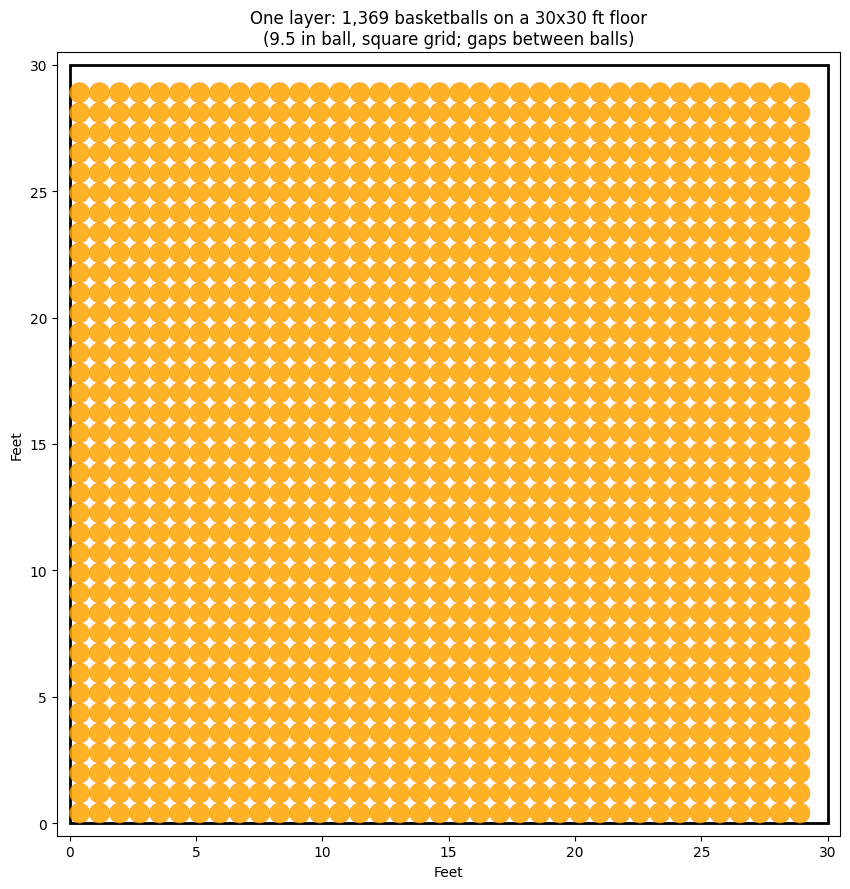

Room model: 900 sq ft floor x 8 ft ceiling (7,200 cu ft).
NBA ball ~9.5 in diameter (0.792 ft).

- One layer on the floor (square grid): about 1,369 balls.
- Roughly filling ceiling height (64% volume packing): about 17,737 balls.
  (Cartoon estimate; real piles pack differently.)

Soho-style ~900 sf per implied unit matches this floor; tighter buildings mean fewer balls.


In [27]:
# Visualize ~900 sq ft: how many basketballs fit in the room?
import matplotlib.patches as mpatches

SQFT = 900
CEILING_FT = 8.0
BALL_D_IN = 9.5
PACKING = 0.64

side = SQFT**0.5  # 30 by 30 ft floor
d_ft = BALL_D_IN / 12.0
r_ft = d_ft / 2.0
vol_ball = (4.0 / 3.0) * np.pi * r_ft**3
vol_room = SQFT * CEILING_FT
n_3d = (vol_room / vol_ball) * PACKING

nx = int(np.floor(side / d_ft))
ny = int(np.floor(side / d_ft))
n_one_layer = nx * ny

fig, ax = plt.subplots(figsize=(9, 9))
room = mpatches.Rectangle((0, 0), side, side, fill=False, edgecolor="black", linewidth=2)
ax.add_patch(room)

for i in range(nx):
    for j in range(ny):
        cx = d_ft / 2 + i * d_ft
        cy = d_ft / 2 + j * d_ft
        ax.add_patch(
            plt.Circle(
                (cx, cy),
                r_ft,
                facecolor="orange",
                edgecolor="darkorange",
                linewidth=0.4,
                alpha=0.85,
            )
        )

ax.set_xlim(-0.5, side + 0.5)
ax.set_ylim(-0.5, side + 0.5)
ax.set_aspect("equal")
ax.set_xlabel("Feet")
ax.set_ylabel("Feet")
ax.set_title(
    f"One layer: {n_one_layer:,} basketballs on a {side:.0f}x{side:.0f} ft floor\n"
    f"({BALL_D_IN} in ball, square grid; gaps between balls)"
)

plt.tight_layout()
plt.show()

print(f"Room model: {SQFT:.0f} sq ft floor x {CEILING_FT:.0f} ft ceiling ({vol_room:,.0f} cu ft).")
print(f"NBA ball ~{BALL_D_IN} in diameter ({d_ft:.3f} ft).")
print()
print(f"- One layer on the floor (square grid): about {n_one_layer:,} balls.")
print(f"- Roughly filling ceiling height ({PACKING:.0%} volume packing): about {n_3d:,.0f} balls.")
print("  (Cartoon estimate; real piles pack differently.)")
print()
print("Soho-style ~900 sf per implied unit matches this floor; tighter buildings mean fewer balls.")


In [28]:
# Compare ML models for sale price (same train/test split; target = log1p(price), metrics in dollars)
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor

_df = manhattan_rentals.copy()
y_raw = pd.to_numeric(_df["SALE PRICE"], errors="coerce")
X = _df.drop(columns=["SALE PRICE"])
ok = y_raw.notna()
X, y_raw = X.loc[ok], y_raw.loc[ok]
y_log = np.log1p(y_raw.values)

obj_cols = list(X.select_dtypes(include=["object", "string", "category"]).columns)
X_enc = pd.get_dummies(X, columns=obj_cols, drop_first=False)
X_enc = X_enc.apply(pd.to_numeric, errors="coerce")
X_enc = X_enc.replace([np.inf, -np.inf], np.nan)
X_enc = X_enc.fillna(X_enc.median())

X_train, X_test, y_train_log, y_test_log, y_train_raw, y_test_raw = train_test_split(
    X_enc, y_log, y_raw.values, test_size=0.2, random_state=42
)
print(f"Features after encoding: {X_enc.shape[1]} columns, {len(X_enc)} rows.")
print(f"Train {len(X_train)} / test {len(X_test)}")


Features after encoding: 90 columns, 517 rows.
Train 413 / test 104


In [29]:
# Fit Ridge, Random Forest, and histogram-based gradient boosting; CV R² on train (log scale); test metrics in $
models = {
    "Ridge (L2 linear)": Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", Ridge(alpha=3.0)),
        ]
    ),
    "Random Forest": Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            (
                "model",
                RandomForestRegressor(
                    n_estimators=400,
                    max_depth=24,
                    min_samples_leaf=2,
                    random_state=42,
                    n_jobs=-1,
                ),
            ),
        ]
    ),
    "HistGradientBoosting": Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            (
                "model",
                HistGradientBoostingRegressor(
                    max_depth=10,
                    max_iter=400,
                    learning_rate=0.06,
                    random_state=42,
                ),
            ),
        ]
    ),
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)
summary_rows = []
fitted = {}

for name, pipe in models.items():
    scores = cross_val_score(
        pipe, X_train, y_train_log, cv=cv, scoring="r2", n_jobs=-1
    )
    pipe.fit(X_train, y_train_log)
    fitted[name] = pipe
    pred_log = pipe.predict(X_test)
    pred_dollars = np.expm1(pred_log)
    mae = mean_absolute_error(y_test_raw, pred_dollars)
    rmse = mean_squared_error(y_test_raw, pred_dollars) ** 0.5
    r2 = r2_score(y_test_raw, pred_dollars)
    summary_rows.append(
        {
            "model": name,
            "CV R2 (log) mean": scores.mean(),
            "CV R2 (log) std": scores.std(),
            "test MAE ($)": mae,
            "test RMSE ($)": rmse,
            "test R2 ($)": r2,
        }
    )
    print(f"{name}: CV R2(log) = {scores.mean():.3f} (+/- {scores.std():.3f})")
    print(f"  Test  MAE=${mae:,.0f}  RMSE=${rmse:,.0f}  R2={r2:.3f}\n")

summary = pd.DataFrame(summary_rows).set_index("model")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
print("Leaderboard (sorted by test R2 on dollar scale, higher is better):")
print(
    summary.sort_values("test R2 ($)", ascending=False).to_string(
        formatters={
            "CV R2 (log) mean": "{:.4f}".format,
            "CV R2 (log) std": "{:.4f}".format,
            "test MAE ($)": lambda x: f"${x:,.0f}",
            "test RMSE ($)": lambda x: f"${x:,.0f}",
            "test R2 ($)": "{:.4f}".format,
        }
    )
)


Ridge (L2 linear): CV R2(log) = 0.312 (+/- 0.112)
  Test  MAE=$32,737,100  RMSE=$130,412,799  R2=-28.628

Random Forest: CV R2(log) = 0.980 (+/- 0.020)
  Test  MAE=$2,226,539  RMSE=$17,635,636  R2=0.458

HistGradientBoosting: CV R2(log) = 0.978 (+/- 0.008)
  Test  MAE=$2,145,677  RMSE=$15,536,822  R2=0.579

Leaderboard (sorted by test R2 on dollar scale, higher is better):
                     CV R2 (log) mean CV R2 (log) std test MAE ($) test RMSE ($) test R2 ($)
model                                                                                       
HistGradientBoosting           0.9783          0.0082   $2,145,677   $15,536,822      0.5795
Random Forest                  0.9803          0.0202   $2,226,539   $17,635,636      0.4582
Ridge (L2 linear)              0.3115          0.1120  $32,737,100  $130,412,799    -28.6284


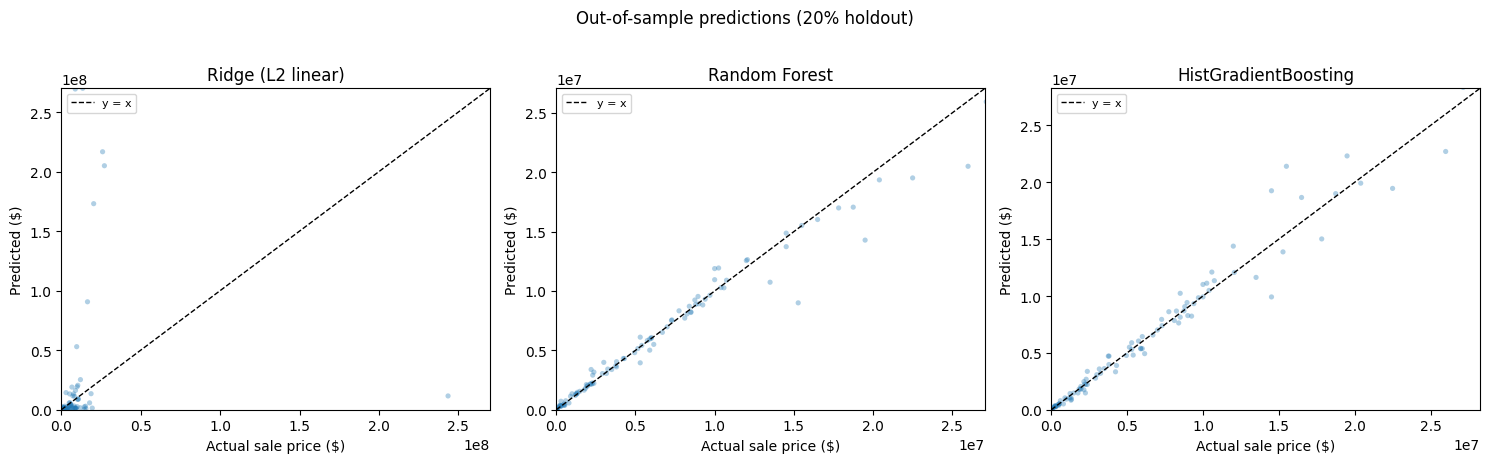


Why results differ (short):
- Ridge: linear in the (scaled) encoded features; strong regularization; smooth extrapolation;
  cannot learn sharp neighborhood-specific steps unless the dummies already encode them.
- Random Forest: many deep trees average votes — captures non-linearities and interactions
  (e.g. GSF × neighborhood) with piecewise rules; can plateau outside training support.
- HistGradientBoosting: trees added sequentially to reduce residual error — often best RMSE
  on tabular data here; still a tree model so similar extrapolation limits as RF.

All models use the same log1p(price) target so large and small sales are treated more evenly;
metrics above convert predictions back to dollars with expm1 for interpretability.



In [30]:
# Diagnostic plots + how these architectures differ on this tabular problem
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, name in zip(axes, fitted.keys()):
    pred_d = np.expm1(fitted[name].predict(X_test))
    ax.scatter(y_test_raw, pred_d, alpha=0.35, s=14, edgecolors="none")
    hi = np.nanpercentile(np.concatenate([y_test_raw, pred_d]), 99)
    ax.plot([0, hi], [0, hi], "k--", lw=1, label="y = x")
    ax.set_xlim(0, hi)
    ax.set_ylim(0, hi)
    ax.set_xlabel("Actual sale price ($)")
    ax.set_ylabel("Predicted ($)")
    ax.set_title(name)
    ax.legend(loc="upper left", fontsize=8)
plt.suptitle("Out-of-sample predictions (20% holdout)", y=1.02)
plt.tight_layout()
plt.show()

print(
    """
Why results differ (short):
- Ridge: linear in the (scaled) encoded features; strong regularization; smooth extrapolation;
  cannot learn sharp neighborhood-specific steps unless the dummies already encode them.
- Random Forest: many deep trees average votes — captures non-linearities and interactions
  (e.g. GSF × neighborhood) with piecewise rules; can plateau outside training support.
- HistGradientBoosting: trees added sequentially to reduce residual error — often best RMSE
  on tabular data here; still a tree model so similar extrapolation limits as RF.

All models use the same log1p(price) target so large and small sales are treated more evenly;
metrics above convert predictions back to dollars with expm1 for interpretability.
"""
)
